#### Code to plot LJ in order to ensure it is unshifted and to pick cluster cutoffs

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Generate LJ function
sorted_distances = np.linspace(0.1, 100, 1000)
epsilon = 0.2385205545
sigma = 3.405
lj_potential = 4 * epsilon * ((sigma / sorted_distances)**12 - (sigma / sorted_distances)**6)

-0.0013986922630159096
3.8000000000000003 -0.23822474374542055


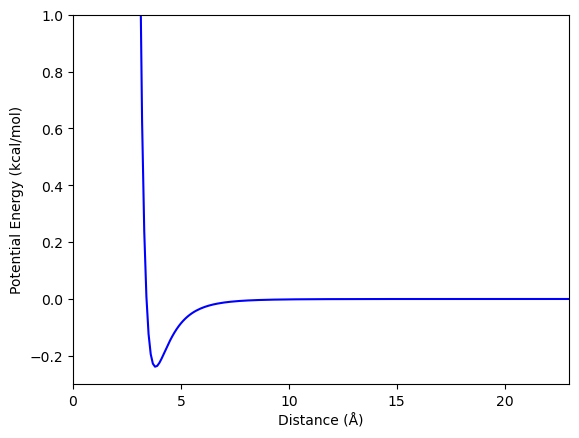

In [18]:
# Plot 
plt.plot(sorted_distances, lj_potential, label='LJ Potential', color='blue')
plt.xlim(0, 6.75*sigma)
plt.ylim(-0.3, 1)
plt.xlabel('Distance (Å)')
plt.ylabel('Potential Energy (kcal/mol)')

# Find the index of the minimum potential energy
min_idx = np.argmin(lj_potential)
min_distance = sorted_distances[min_idx]
min_energy = lj_potential[min_idx]
print(lj_potential[100])
print(min_distance, min_energy)

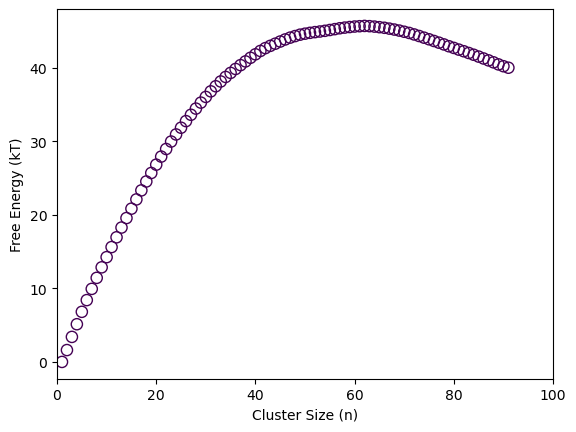

In [81]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.cm import viridis
from matplotlib.colors import to_hex
from matplotlib.lines import Line2D

def parse(file_path):
    data_lines = []
    header_line = None
    with open(file_path, 'r') as file:
        for line in file:
            if line.startswith('#') and header_line is None:  # Look for the first header line
                header_line = line[1:].split()[0:3]  # Remove the '#' and strip whitespace
            elif not line.startswith('#') and header_line is not None:  # Read data lines after the header
                data_lines.append(line.split()[0:3])
    # Check if we got any data
    if not data_lines:
        raise ValueError("No data found in the file.")
    # Check if header_line is found
    if header_line is None:
        raise ValueError("Header line not found in the file.")
    return pd.DataFrame(data_lines, columns=header_line).astype(float)

colors = [to_hex(viridis(i)) for i in np.linspace(0, 1, 7)]


pmf = parse("/Users/mdog/Library/CloudStorage/OneDrive-UW/00_nucleation/01_PMFs/data/argon_energy.txt")
plt.scatter(pmf.iloc[:,0], pmf.iloc[:,1], edgecolor=colors[0], facecolor='none', s=65, marker='o')

plt.xlabel("Cluster Size (n)")
plt.ylabel("Free Energy (kT)")
plt.xlim(0,100)
plt.savefig("/Users/mdog/Desktop/pmf_plot.png", dpi=300, bbox_inches='tight', transparent=True)
# plt.ylim(-50, 50)